# PGD Attack on MNIST-10

**Objective.** Craft adversarial examples for a 10-class MNIST digit classifier using the Projected Gradient Descent (PGD) white-box attack, then train a binary detector that tries to catch those perturbations and see why it does not generalize across attack strengths.

## What you will do

1. Load the MNIST dataset and train a small CNN classifier from scratch.
2. Configure and run the PGD attack with the Adversarial Robustness Toolbox (ART) to generate adversarial examples.
3. Measure the damage: clean accuracy vs. adversarial accuracy, and the size of the perturbation.
4. Visualize clean vs. adversarial digits alongside the model's predictions.
5. Generate a balanced clean/adversarial dataset and train a binary detector, then sweep the attack strength to test whether detection generalizes.

## Prerequisites

- Comfortable with CNNs, the white-box threat model (the attacker knows the architecture, weights, and loss, and can compute the gradient of the loss with respect to the input), the L-infinity norm, and cross-entropy loss.

## Running this notebook

This is a self-contained notebook: it downloads MNIST, trains its own classifier, and generates its own adversarial examples, so no external model or dataset files are required. Run the cells top to bottom, on Colab or locally. Training the classifier and generating PGD examples are the two slower steps; everything else is fast.

## Background: the PGD attack

PGD (Madry et al., 2018) is the iterative extension of the single-step Fast Gradient Sign Method (FGSM). It answers the *max-loss* question: within a fixed perturbation budget, find the perturbation that most increases the classifier's loss. Each step is:

$$x^{i+1} = \Pi_{\epsilon\text{-ball}}\Big(x^{i} + \alpha \cdot \text{sign}\big(\nabla_x L(f(x^{i}), y)\big)\Big), \quad \text{then clip } x^{i+1} \text{ to } [0, 1].$$

The attack has three defining ingredients:

- **Perturbation budget (epsilon).** The maximum L-infinity distance between the clean and adversarial image: every pixel may change by at most `eps`. This is a hard cap chosen in advance.
- **Random start.** PGD begins from a random point inside the epsilon-ball around the clean image, not from the clean image itself, so repeated runs explore different parts of the loss surface.
- **Iterate, project, clip.** Each step moves by a step size `eps_step` in the sign-of-the-gradient direction, projects the perturbation back inside the epsilon-ball, and clips the image to the valid pixel range `[0, 1]`.

With enough iterations and random restarts, PGD is the strongest first-order (gradient-based) attack and the standard benchmark for evaluating robustness. These three ingredients map directly onto ART's `eps`, `eps_step`, and `max_iter`.

After building the attack, we cross from attacking to defending: we train a binary CNN detector to separate clean from adversarial inputs, then sweep epsilon to show that a detector tuned at one attack strength does **not** generalize to others. Detection is an empirical defense with no guarantee.

## 1. Setup

Install the one external dependency, the Adversarial Robustness Toolbox (ART), then import everything the notebook uses. TensorFlow/Keras, NumPy, and Matplotlib are already available on Colab and in most local ML environments; ART is not, so we install it here.

In [1]:
# ART (Adversarial Robustness Toolbox) provides the PGD attack and the BinaryInputDetector.
# TensorFlow/Keras, NumPy, and Matplotlib are usually pre-installed (e.g. on Colab);
# uncomment the second line if your environment is missing them.
!pip install adversarial-robustness-toolbox
# !pip install tensorflow numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.4 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

# ART components used in this notebook:
# - KerasClassifier wraps a Keras model in ART's estimator interface.
# - ProjectedGradientDescent is the PGD evasion attack.
# - BinaryInputDetector wraps a binary CNN as an adversarial-input detector.
from art.estimators.classification import KerasClassifier
from art.attacks.evasion import ProjectedGradientDescent
from art.defences.detector.evasion import BinaryInputDetector

## 2. Load and prepare the data

MNIST is 28x28 grayscale images of handwritten digits (0-9). We normalize pixels to `[0, 1]`, add a trailing channel axis for the CNN, and one-hot encode the labels. **Normalization matters for PGD:** the perturbation budget `eps` and the classifier's `clip_values` are both expressed on this `[0, 1]` scale, so the data range and the attack settings must agree.

We keep the first 500 test images for the attack and evaluation steps below. PGD is iterative (many gradient steps per image), so evaluating on a smaller slice keeps runtimes reasonable.

In [3]:
# Load MNIST and normalize pixel values from [0, 255] to [0, 1].
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add a channel axis: (N, 28, 28) -> (N, 28, 28, 1).
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# One-hot encode labels for the 10 digit classes.
nb_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes=nb_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=nb_classes)

# Work with the first 500 test samples to keep PGD generation tractable.
x_test = x_test[:500]
y_test = y_test[:500]

print("x_train:", x_train.shape, "x_test:", x_test.shape, "pixel range:", (float(x_test.min()), float(x_test.max())))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28, 1) x_test: (500, 28, 28, 1) pixel range: (0.0, 1.0)


### A quick look at the clean data

Before training or attacking anything, sanity-check the inputs: one clean example per digit class, shown in grayscale. If these look wrong, every downstream figure will be unreliable.

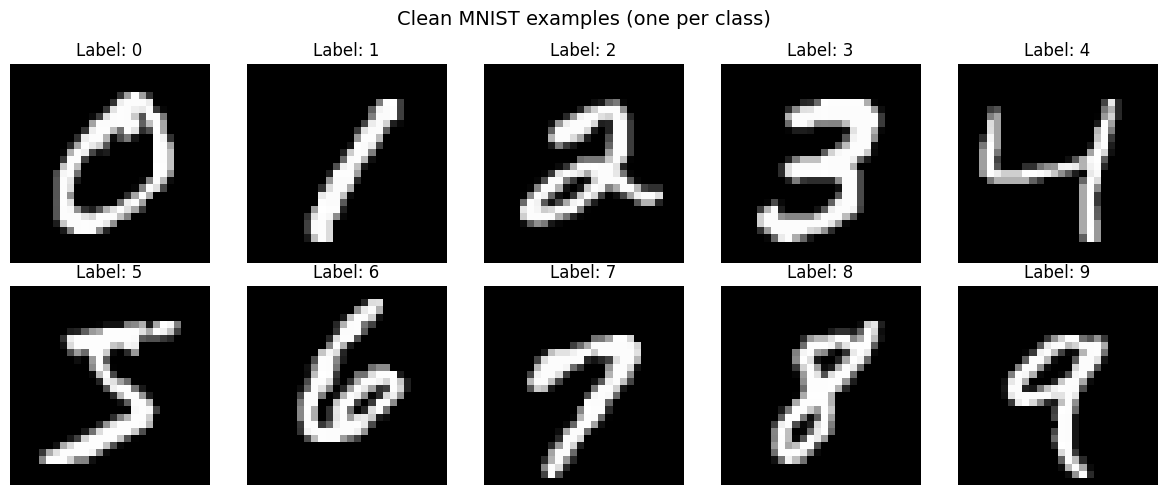

In [4]:
# Show one clean example per digit (0-9) in grayscale.
train_labels = np.argmax(y_train, axis=1)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    idx = np.where(train_labels == i)[0][0]
    ax.imshow(x_train[idx].squeeze(), cmap='gray')
    ax.set_title(f"Label: {i}", fontsize=12)
    ax.axis('off')
fig.suptitle("Clean MNIST examples (one per class)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Build and train the target model

The target is a small CNN: three convolution+pooling blocks feeding into two dense layers (a 128-unit hidden layer and a 10-way softmax output). We train it from scratch on clean MNIST with no adversarial defenses, so any accuracy drop under attack can be attributed to the attack rather than to weak or defended training.

We reuse this same architecture later for the clean-vs-adversarial detector, just with a 2-class output instead of 10.

In [5]:
def build_cnn_classifier(num_classes):
    """3 conv blocks + 2 dense layers. Used for both the target classifier
    (num_classes=10) and the clean-vs-adversarial detector (num_classes=2)."""
    return tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])


In [6]:
model = build_cnn_classifier(nb_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the target classifier on clean MNIST. A handful of epochs is enough
# for this architecture to reach roughly 99% clean test accuracy.
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8893 - loss: 0.3567 - val_accuracy: 0.9683 - val_loss: 0.1053
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9684 - loss: 0.1023 - val_accuracy: 0.9830 - val_loss: 0.0560
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9770 - loss: 0.0747 - val_accuracy: 0.9837 - val_loss: 0.0551
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9814 - loss: 0.0589 - val_accuracy: 0.9863 - val_loss: 0.0433
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9849 - loss: 0.0486 - val_accuracy: 0.9885 - val_loss: 0.0392


## 4. Configure and run the PGD attack

### Wrap the model for ART

ART attacks operate on an *estimator*, not a raw Keras model. We wrap the classifier with `KerasClassifier` and tell ART the valid pixel range via `clip_values=(0.0, 1.0)`. ART clips every adversarial example back into this range, so the perturbed inputs remain valid images.

In [8]:
# Wrap the target model in ART's estimator interface.
# clip_values must match the normalized pixel range [0.0, 1.0].
classifier = KerasClassifier(model=model, clip_values=(0.0, 1.0), use_logits=False)

### Build the attack

PGD's behavior is set by three parameters:

| Parameter | Symbol | Role |
|-----------|--------|------|
| `eps` | epsilon | L-infinity perturbation budget: the maximum change allowed per pixel (here `0.2` on the `[0, 1]` scale). Larger `eps` gives a stronger but more visible attack. |
| `eps_step` | alpha | Step size taken each iteration. A useful rule of thumb is `eps_step` approximately `eps / max_iter` so the total path length matches the budget. |
| `max_iter` | T | Number of gradient-ascent + projection iterations. More iterations explore the perturbation space more thoroughly, at higher cost. |

The `ProjectedGradientDescent` object below targets our wrapped `classifier`. You can change these parameters later with `attack_pgd.set_params(eps=...)` without rebuilding the object, which is exactly what the strength sweep at the end does.

In [9]:
# Instantiate PGD against the wrapped classifier.
# eps = perturbation budget, eps_step = per-iteration step size, max_iter = number of iterations.
attack_pgd = ProjectedGradientDescent(
    estimator=classifier,
    eps=0.2,
    eps_step=0.01,
    max_iter=40,
)

### Generate adversarial examples

We run PGD on the 500 held-out test images to produce `x_test_adv`. This is the compute-heavy step in the notebook (40 iterations per image), so it can take a little while.

In [10]:
# Generate PGD adversarial examples for the 500 test images (eps = 0.2).
x_test_adv = attack_pgd.generate(x=x_test)

print("x_test_adv:", x_test_adv.shape, "y_test:", y_test.shape)

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

x_test_adv: (500, 28, 28, 1) y_test: (500, 10)


## 5. Evaluate the attack

Two numbers tell the story:

- **Accuracy drop.** Clean accuracy (near 99%) vs. adversarial accuracy (near 0%). The gap is the fooling rate.
- **Perturbation size.** The mean absolute per-pixel change and the L-infinity norm. A tiny perturbation that collapses accuracy is what makes adversarial examples alarming; the L-infinity norm should stay within the budget `eps = 0.2`.

In [11]:
# Clean accuracy on the 500 clean test images.
_, clean_acc = model.evaluate(x_test, y_test, verbose=0)

# Adversarial accuracy on the PGD examples.
_, adv_acc = model.evaluate(x_test_adv, y_test, verbose=0)

# Perturbation size between clean and adversarial images.
mean_abs = np.mean(np.abs(x_test_adv - x_test))
linf = np.max(np.abs(x_test_adv - x_test))

print(f"Clean accuracy:        {clean_acc * 100:5.2f}%")
print(f"Adversarial accuracy:  {adv_acc * 100:5.2f}%")
print(f"Fooling rate:          {(clean_acc - adv_acc) * 100:5.2f} percentage points")
print(f"Mean |perturbation|:   {mean_abs:.4f}  (per pixel, on the [0, 1] scale)")
print(f"L-infinity norm:       {linf:.4f}  (should be <= eps = 0.2)")

Clean accuracy:        98.80%
Adversarial accuracy:   5.00%
Fooling rate:          93.80 percentage points
Mean |perturbation|:   0.0635  (per pixel, on the [0, 1] scale)
L-infinity norm:       0.2000  (should be <= eps = 0.2)


## 6. Visualize clean vs. adversarial examples

The top row shows clean digits with the model's prediction; the bottom row shows the PGD version of the same digit with the model's (now usually wrong) prediction. The two rows look nearly identical to the human eye, yet the predictions flip. Green titles mark correct predictions, red marks the misclassifications the attack caused.

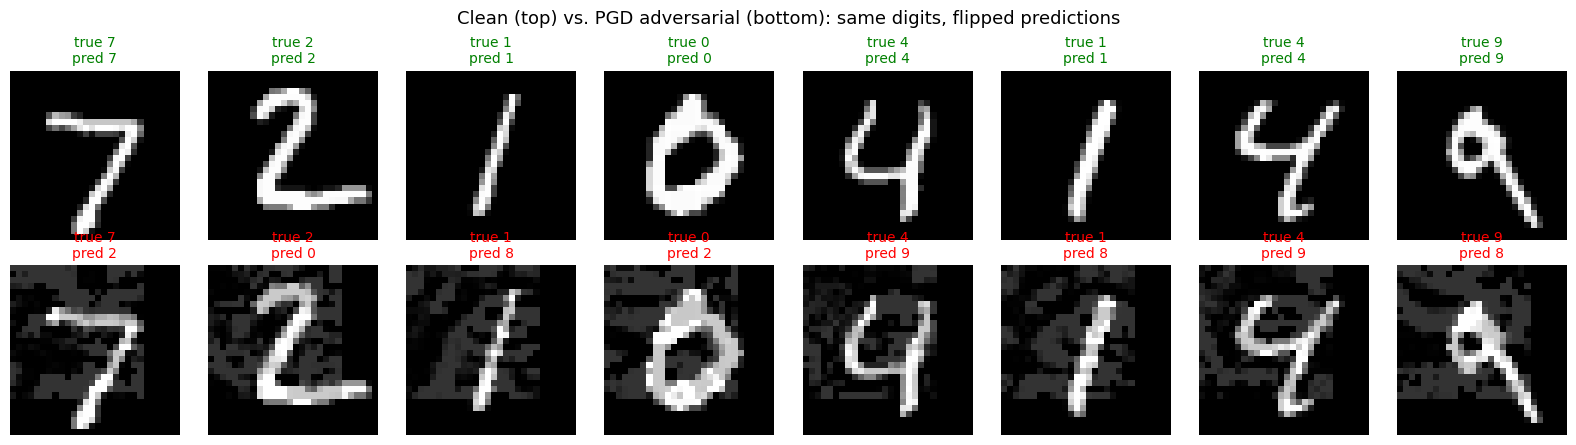

In [12]:
# Compare clean and adversarial versions of the same images side by side.
n = 8
clean_preds = np.argmax(model.predict(x_test[:n], verbose=0), axis=1)
adv_preds = np.argmax(model.predict(x_test_adv[:n], verbose=0), axis=1)
true_labels = np.argmax(y_test[:n], axis=1)

fig, axes = plt.subplots(2, n, figsize=(2 * n, 4.5))
for j in range(n):
    # Top row: clean image.
    axes[0, j].imshow(x_test[j].squeeze(), cmap='gray')
    color = 'green' if clean_preds[j] == true_labels[j] else 'red'
    axes[0, j].set_title(f"true {true_labels[j]}\npred {clean_preds[j]}", fontsize=10, color=color)
    axes[0, j].axis('off')

    # Bottom row: adversarial image.
    axes[1, j].imshow(x_test_adv[j].squeeze(), cmap='gray')
    color = 'green' if adv_preds[j] == true_labels[j] else 'red'
    axes[1, j].set_title(f"true {true_labels[j]}\npred {adv_preds[j]}", fontsize=10, color=color)
    axes[1, j].axis('off')

fig.suptitle("Clean (top) vs. PGD adversarial (bottom): same digits, flipped predictions", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Adversarial-example detector

We now switch sides and build a defense: a binary CNN that classifies each input as **clean** or **adversarial**. It is trained on a balanced 50/50 mix of clean images and their PGD counterparts. The idea is that PGD leaves a consistent, gradient-aligned signature in feature space that a CNN can learn to spot, even though the perturbation is invisible to us.

### Generate the detector training data

We take 500 clean training images (disjoint from the test set used above) and attack them with the same PGD attack at `eps = 0.2` to get 500 adversarial counterparts. Stacking the two gives a balanced set of 1000 samples with binary labels: `[1, 0]` = clean, `[0, 1]` = adversarial.

In [13]:
# 500 clean training images and their PGD-adversarial counterparts (eps = 0.2).
x_train_clean_detector = x_train[:500]
x_train_adv_detector = attack_pgd.generate(x=x_train_clean_detector)

x_train_detector = np.concatenate([x_train_clean_detector, x_train_adv_detector], axis=0)
y_train_detector = np.concatenate([
    np.tile([1, 0], (500, 1)),   # clean
    np.tile([0, 1], (500, 1)),   # adversarial
], axis=0).astype("float32")

# Shuffle so clean/adversarial examples are interleaved during training.
shuffle_idx = np.random.permutation(len(x_train_detector))
x_train_detector = x_train_detector[shuffle_idx]
y_train_detector = y_train_detector[shuffle_idx]

print("x_train_detector:", x_train_detector.shape, "y_train_detector:", y_train_detector.shape)

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

x_train_detector: (1000, 28, 28, 1) y_train_detector: (1000, 2)


### Build and train the detector

The detector reuses the same `build_cnn_classifier` architecture as the target model (3 conv blocks + 2 dense layers), just with a 2-class softmax head (clean vs. adversarial) instead of 10. A few epochs on the balanced set are enough, because the two classes form well-separated clusters in feature space.

In [14]:
# Binary CNN detector: same architecture as the classifier, with a 2-class output head.
detector_model = build_cnn_classifier(2)
detector_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

detector_model.fit(x_train_detector, y_train_detector, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.7270 - loss: 0.5782
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9860 - loss: 0.0694
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9950 - loss: 0.0162
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0052
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 8.1018e-04
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 4.8013e-04
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 3.0569e-04
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 2.2160e-04
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.6861e-04
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.3938e-04


### Wrap the detector with ART's BinaryInputDetector

`BinaryInputDetector` gives the detector the same ART interface as the attack, so `detect(x)` returns a per-sample adversarial flag. We wrap the trained Keras model with `KerasClassifier` (again with `clip_values=(0.0, 1.0)`) and hand it to the detector.

In [15]:
# Wrap the trained detector as an ART estimator, then in a BinaryInputDetector.
detector_classifier = KerasClassifier(model=detector_model, clip_values=(0.0, 1.0), use_logits=False)
detector = BinaryInputDetector(detector_classifier)

# Fit the detector within ART's interface on the balanced training set.
detector.fit(x_train_detector, y_train_detector, nb_epochs=3, batch_size=32)

### How well does the detector catch the eps = 0.2 attack?

We check both sides of the trade-off: how many of the 500 test-set adversarial images it flags (true positives), and how many of the 500 clean test images it wrongly flags (false positives). At the strength it was trained on, the detector should catch almost every adversarial example while rarely tripping on clean data.

In [16]:
# Flagged adversarial examples (true positives).
_, flags_adv = detector.detect(x_test_adv)
n_flag_adv = int(np.sum(flags_adv))

# Flagged clean examples (false positives).
_, flags_clean = detector.detect(x_test)
n_flag_clean = int(np.sum(flags_clean))

print(f"Adversarial images flagged: {n_flag_adv} / {len(x_test_adv)}  (higher is better)")
print(f"Clean images flagged:       {n_flag_clean} / {len(x_test)}  (lower is better)")

Adversarial images flagged: 500 / 500  (higher is better)
Clean images flagged:       1 / 500  (lower is better)


### Does the detector generalize across attack strengths?

The detector was trained only on `eps = 0.2` examples. Now we sweep epsilon from very weak to very strong, regenerating PGD examples at each strength, and count two things per 100 images:

- how many the **detector flags** as adversarial, and
- how many actually **fool the classifier**.

If detection were a general defense, the flagged curve would track the fooled curve everywhere. Watch what happens instead at strengths far from `0.2`.

> This cell runs PGD live at each epsilon, so it is the slowest step in the notebook. Shorten `eps_range` or reduce `n_samples` to speed it up.

In [17]:
# Sweep the perturbation budget. The detector was trained at eps = 0.2 only.
eps_range = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
n_samples = 100
x_probe = x_test[:n_samples]
y_probe = np.argmax(y_test[:n_samples], axis=1)

n_flagged = []   # detector flags per 100 samples
n_fooled = []    # classifier errors per 100 samples

for eps in eps_range:
    # Rescale the step size with the budget so each attack fully uses its epsilon.
    attack_pgd.set_params(eps=eps, eps_step=eps / 4.0)
    x_adv = attack_pgd.generate(x=x_probe)
    n_flagged.append(int(np.sum(detector.detect(x_adv)[1])))
    preds = np.argmax(classifier.predict(x_adv), axis=1)
    n_fooled.append(int(np.sum(preds != y_probe)))

# Prepend the clean (eps = 0) baseline for reference.
clean_preds = np.argmax(classifier.predict(x_probe), axis=1)
eps_axis = [0.0] + eps_range
n_flagged = [n_flag_clean] + n_flagged
n_fooled = [int(np.sum(clean_preds != y_probe))] + n_fooled

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

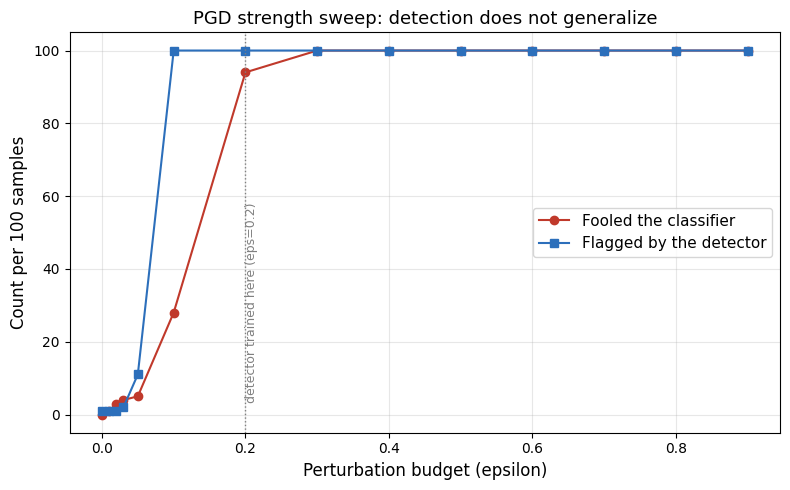

In [18]:
# Plot detector flags against classifier fooling as attack strength varies.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eps_axis, n_fooled, marker='o', color='#c0392b', label='Fooled the classifier')
ax.plot(eps_axis, n_flagged, marker='s', color='#2c6fbb', label='Flagged by the detector')

# Mark the single strength the detector was trained on.
ax.axvline(0.2, color='gray', linestyle=':', linewidth=1)
ax.text(0.2, ax.get_ylim()[1] * 0.02, ' detector trained here (eps=0.2)',
        rotation=90, va='bottom', ha='left', fontsize=9, color='gray')

ax.set_xlabel('Perturbation budget (epsilon)', fontsize=12)
ax.set_ylabel(f'Count per {n_samples} samples', fontsize=12)
ax.set_title('PGD strength sweep: detection does not generalize', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='center right', fontsize=11)
plt.tight_layout()
plt.show()

> **Takeaway.** The detector is reliable only near the strength it was trained on (`eps = 0.2`). Turn the attack down and adversarial examples can still slip past while barely denting accuracy; turn it up and the flagged and fooled curves diverge. A detector calibrated at one epsilon does **not** generalize across the strength spectrum. Detection is an *empirical* defense: it works against the attacks you trained it on and offers no guarantee against the ones you did not.

## Key takeaways

- **PGD is a strong white-box attack.** Iterating FGSM with a random start, per-step projection, and clipping to `[0, 1]` collapses a ~99% MNIST classifier to near-zero accuracy with a perturbation that is invisible to the human eye.
- **The budget epsilon controls the trade-off.** Larger `eps` gives a stronger, more visible attack; the L-infinity norm of every adversarial example stays within `eps`.
- **Detection is empirical, not guaranteed.** A binary detector trained at one attack strength catches that strength well but fails to generalize across the epsilon spectrum: detection works against the attacks you trained it on and nothing more.
- **Stronger defenses exist beyond detection**, such as adversarial training and certified methods like randomized smoothing, but they are outside the scope of this notebook.